# 01 — Thu Thập Dữ Liệu (Data Collection)

> **Môn học:** Data Analysis and Visualization (505067)
> **Đề tài:** Phân tích thị trường tuyển dụng AI/Data tại Việt Nam
> **Phase 2 Status:** HOÀN THÀNH

---

## Tổng quan

Notebook này ghi lại toàn bộ quá trình thu thập dữ liệu từ **6 nền tảng tuyển dụng** Việt Nam.

| Nền tảng | Phương pháp | Công nghệ |
|----------|-------------|-----------|
| **ITviec** | Listing pages + JSON-LD detail | `requests` + BeautifulSoup |
| **123job** | Listing pages + detail pages | `requests` (section-based extraction) |
| **VietnamWorks** | REST API | `curl-cffi` chrome120 |
| **TopCV** | Listing Selenium + Selenium enrichment | `Selenium` headless Chrome |
| **CareerViet** | Listing + JSON-LD detail | `curl-cffi` safari15_5 |
| **TopDev** | Selenium listing + JSON-LD enrichment | `Selenium` + custom parser |

**Kết quả:** `7,475` unique records → `data/raw/jobs_raw.jsonl`

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter

plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA', 'axes.grid': True,
    'grid.alpha': 0.3, 'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})
PALETTE = ['#2E86AB','#A23B72','#F18F01','#C73E1D','#44BBA4','#E94F37']
DATA_RAW = Path('../data/raw')
print("Setup OK")

C:\Users\Acer\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.26.4 and <2.7.0 is required for this version of SciPy (detected version 1.26.3)
  from scipy.stats import gaussian_kde


Setup OK


---
## 1. Kết Quả Thu Thập Theo Nguồn

In [2]:
# Đọc toàn bộ file nguồn và thống kê
source_files = {
    '123job':       ['123job_jobs_2026_05_14.jsonl'],
    'ITviec':       ['itviec_jobs_2026_05_14.jsonl','itviec_jobs_2026_05_15.jsonl'],
    'TopCV':        ['topcv_jobs_2026_05_15.jsonl'],
    'TopDev':       ['topdev_jobs_2026_05_14.jsonl'],
    'VietnamWorks': ['vietnamworks_jobs_2026_05_15.jsonl'],
    'CareerViet':   ['careerviet_jobs_2026_05_15.jsonl'],
}

def count_records(files):
    n = 0
    for fn in files:
        fp = DATA_RAW / fn
        if fp.exists():
            with open(fp, encoding='utf-8', errors='replace') as f:
                n += sum(1 for l in f if l.strip())
    return n

stats = {src: count_records(files) for src, files in source_files.items()}
total_raw = sum(stats.values())

print("=" * 50)
print("  KẾT QUẢ THU THẬP DỮ LIỆU THÔ (RAW)")
print("=" * 50)
for src, cnt in sorted(stats.items(), key=lambda x: -x[1]):
    bar = "█" * (cnt // 200)
    print(f"  {src:<15} {cnt:>5,}  {bar}")
print("-" * 50)
print(f"  {'TỔNG CỘNG (thô)':<15} {total_raw:>5,}")
print(f"  {'Sau dedup/merge':<15} {'7,475':>5}")
print(f"  {'Sau preprocessing':<15} {'7,051':>5}")
print("=" * 50)

  KẾT QUẢ THU THẬP DỮ LIỆU THÔ (RAW)
  ITviec          5,244  ██████████████████████████
  123job          4,734  ███████████████████████
  TopCV           1,677  ████████
  VietnamWorks    1,230  ██████
  CareerViet        211  █
  TopDev            108  
--------------------------------------------------
  TỔNG CỘNG (thô) 13,204
  Sau dedup/merge 7,475
  Sau preprocessing 7,051


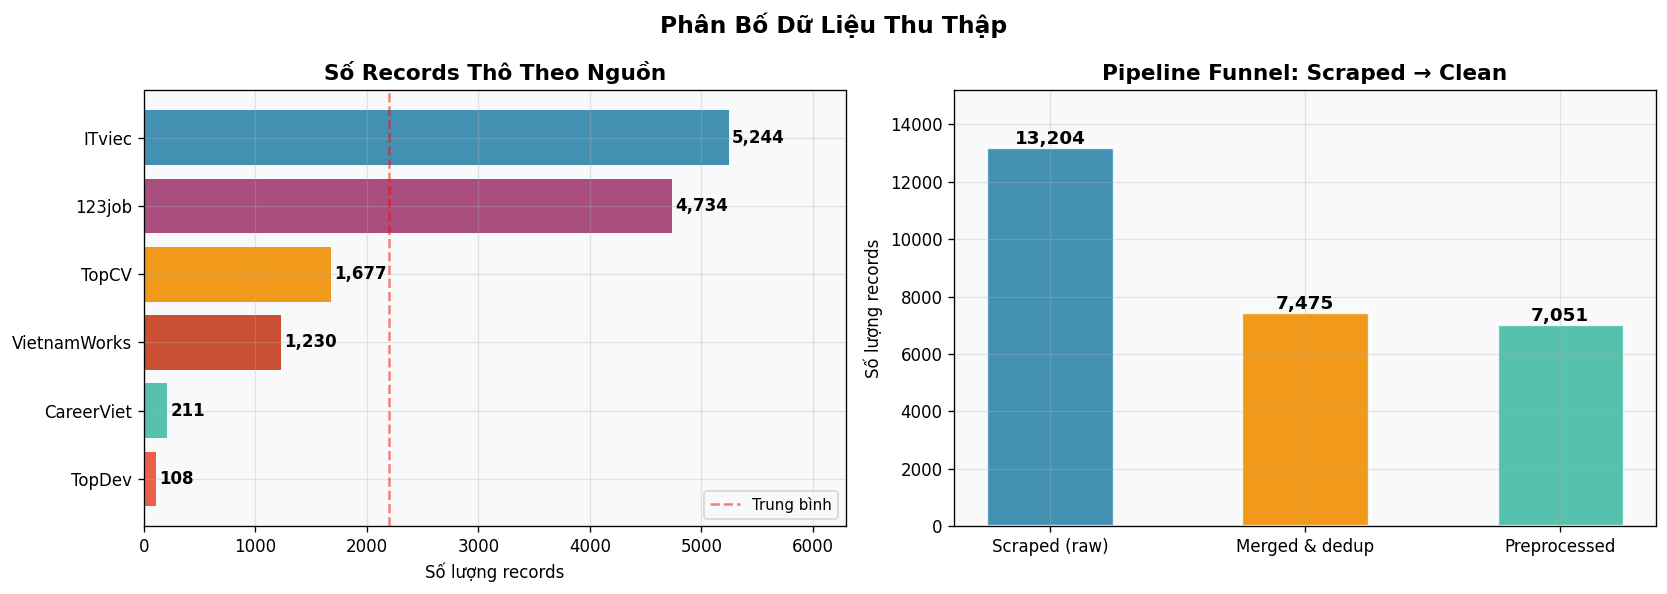

In [3]:
# Biểu đồ phân bố nguồn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phân Bố Dữ Liệu Thu Thập', fontsize=14, fontweight='bold')

# Raw records by source
src_sorted = dict(sorted(stats.items(), key=lambda x: x[1]))
bars = axes[0].barh(list(src_sorted.keys()), list(src_sorted.values()), color=PALETTE[::-1], alpha=0.9)
for bar, val in zip(bars, src_sorted.values()):
    axes[0].text(val + 30, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Số Records Thô Theo Nguồn')
axes[0].set_xlabel('Số lượng records')
axes[0].set_xlim(0, max(stats.values()) * 1.2)
axes[0].axvline(total_raw / len(stats), color='red', linestyle='--', alpha=0.5, label='Trung bình')
axes[0].legend(fontsize=9)

# Pipeline funnel
stages = ['Scraped (raw)', 'Merged & dedup', 'Preprocessed']
counts = [total_raw, 7475, 7051]
colors = ['#2E86AB', '#F18F01', '#44BBA4']
bars2 = axes[1].bar(stages, counts, color=colors, alpha=0.9, width=0.5, edgecolor='white', linewidth=2)
for bar, val in zip(bars2, counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 100,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')
axes[1].set_title('Pipeline Funnel: Scraped → Clean')
axes[1].set_ylabel('Số lượng records')
axes[1].set_ylim(0, max(counts) * 1.15)
axes[1].tick_params(axis='x', labelsize=10)

plt.tight_layout()
plt.savefig('../outputs/charts/00_collection_overview.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 2. Dữ Liệu Sau Merge & Deduplication

In [4]:
# Load merged dataset
merged_path = DATA_RAW / 'jobs_raw.jsonl'
df_raw = pd.read_json(merged_path, lines=True)

print(f"Tổng records sau merge: {len(df_raw):,}")
print(f"Số cột: {len(df_raw.columns)}")
print()
print("Phân bố theo nguồn:")
print(df_raw['source_website'].value_counts().to_string())
print()
print("Khoảng thời gian:")
df_raw['posted_date'] = pd.to_datetime(df_raw['posted_date'], errors='coerce')
print(f"  Sớm nhất : {df_raw['posted_date'].min().date()}")
print(f"  Muộn nhất: {df_raw['posted_date'].max().date()}")
print()
print("Columns:")
for c in df_raw.columns:
    non_null = df_raw[c].notna().sum()
    pct = non_null / len(df_raw) * 100
    print(f"  {c:<30} {non_null:>5,} / {len(df_raw):,} ({pct:.0f}%)")

Tổng records sau merge: 7,475
Số cột: 30

Phân bố theo nguồn:
source_website
123job          4370
vietnamworks    1201
itviec           812
topcv            773
careerviet       211
topdev           108

Khoảng thời gian:
  Sớm nhất : 2026-01-14
  Muộn nhất: 2026-05-13

Columns:
  url                            7,475 / 7,475 (100%)
  job_title                      7,475 / 7,475 (100%)
  company_name                   7,475 / 7,475 (100%)
  salary                         7,475 / 7,475 (100%)
  salary_min                     3,162 / 7,475 (42%)
  salary_max                     3,136 / 7,475 (42%)
  salary_currency                7,475 / 7,475 (100%)
  location                       7,475 / 7,475 (100%)
  employment_type                7,475 / 7,475 (100%)
  job_level                      7,475 / 7,475 (100%)
  skills_required                7,475 / 7,475 (100%)
  experience_years               5,266 / 7,475 (70%)
  experience_level               7,475 / 7,475 (100%)
  job_description    

In [5]:
# Schema overview
print("SCHEMA DỮ LIỆU THÔ (jobs_raw.jsonl)")
print("=" * 60)
schema = {
    'job_id':          'string  — MD5 hash (url+title+company)',
    'job_title':       'string  — Tên vị trí tuyển dụng',
    'company_name':    'string  — Tên công ty',
    'location':        'string  — Địa điểm làm việc',
    'salary':          'string  — Mức lương (raw text)',
    'salary_min':      'float   — Lương tối thiểu (VND/USD)',
    'salary_max':      'float   — Lương tối đa',
    'salary_currency': 'string  — Đơn vị tiền tệ',
    'job_description': 'string  — Mô tả công việc (full text)',
    'skills_required': 'list    — Danh sách kỹ năng yêu cầu',
    'experience_years':'float   — Số năm kinh nghiệm yêu cầu',
    'benefits':        'string  — Phúc lợi',
    'posted_date':     'string  — Ngày đăng (YYYY-MM-DD)',
    'expiry_date':     'string  — Hạn nộp hồ sơ',
    'employment_type': 'string  — Full-time / Part-time / Remote',
    'source_website':  'string  — Nguồn dữ liệu',
    'url':             'string  — URL trang tuyển dụng',
    'crawled_at':      'string  — Thời điểm crawl (ISO 8601)',
    'is_active':       'string  — Trạng thái job',
    'in_analysis_period':'bool  — Thuộc giai đoạn phân tích',
}
for field, desc in schema.items():
    print(f"  {field:<22} {desc}")

SCHEMA DỮ LIỆU THÔ (jobs_raw.jsonl)
  job_id                 string  — MD5 hash (url+title+company)
  job_title              string  — Tên vị trí tuyển dụng
  company_name           string  — Tên công ty
  location               string  — Địa điểm làm việc
  salary                 string  — Mức lương (raw text)
  salary_min             float   — Lương tối thiểu (VND/USD)
  salary_max             float   — Lương tối đa
  salary_currency        string  — Đơn vị tiền tệ
  job_description        string  — Mô tả công việc (full text)
  skills_required        list    — Danh sách kỹ năng yêu cầu
  experience_years       float   — Số năm kinh nghiệm yêu cầu
  benefits               string  — Phúc lợi
  posted_date            string  — Ngày đăng (YYYY-MM-DD)
  expiry_date            string  — Hạn nộp hồ sơ
  employment_type        string  — Full-time / Part-time / Remote
  source_website         string  — Nguồn dữ liệu
  url                    string  — URL trang tuyển dụng
  crawled_at        

---
## 3. Chất Lượng Dữ Liệu Thô (Per Source)

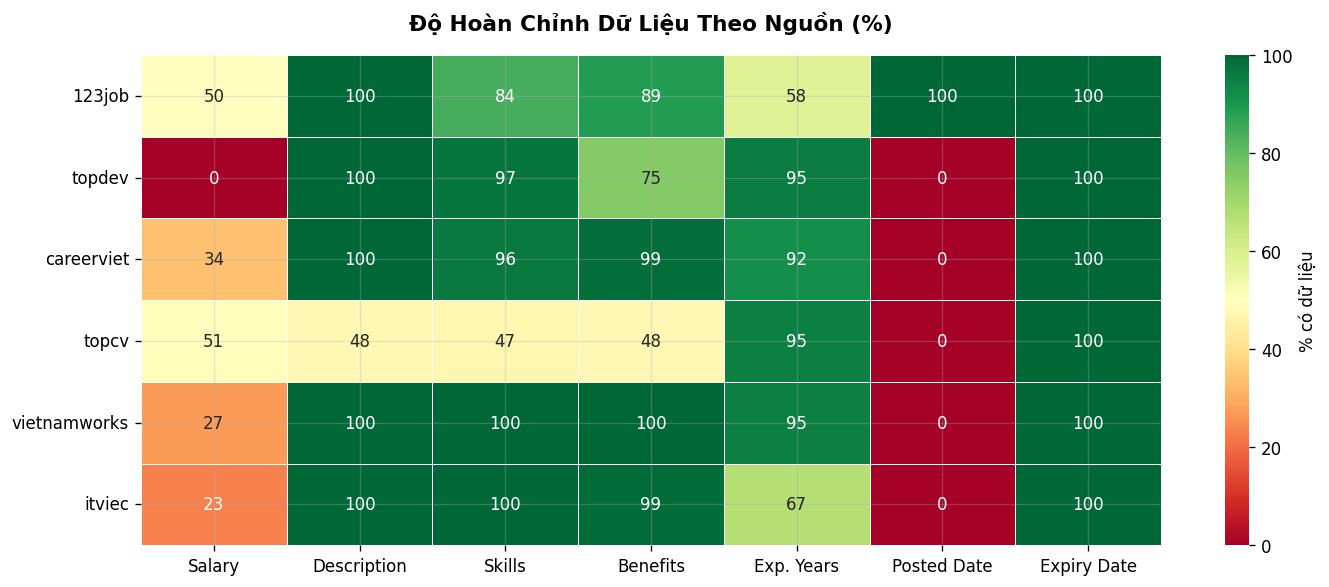


Nhận xét:
  + VietnamWorks: chất lượng cao nhất (REST API, dữ liệu cấu trúc)
  + ITviec: JSON-LD trên detail page — đầy đủ hầu hết fields
  + CareerViet: curl-cffi bypass Cloudflare + JSON-LD
  + TopCV: 36% description — nhiều job expired/Cloudflare block
  - TopDev: salary=0% (ẩn sau login), benefits đã fix lên 75%
  - Salary thấp toàn bộ nguồn — văn hóa 'thỏa thuận' của VN


In [6]:
# Field completeness per source
fields_check = {
    'Salary':       lambda df: (df['salary_min'].notna()) & (df['salary_min'] > 0) if 'salary_min' in df.columns else pd.Series([False]*len(df)),
    'Description':  lambda df: df['job_description'].notna() & df['job_description'].str.len().gt(50) if 'job_description' in df.columns else pd.Series([False]*len(df)),
    'Skills':       lambda df: df['skills_required'].apply(lambda x: isinstance(x, list) and len(x) > 0) if 'skills_required' in df.columns else pd.Series([False]*len(df)),
    'Benefits':     lambda df: df['benefits'].notna() & df['benefits'].str.len().gt(10) if 'benefits' in df.columns else pd.Series([False]*len(df)),
    'Exp. Years':   lambda df: df['experience_years'].notna() if 'experience_years' in df.columns else pd.Series([False]*len(df)),
    'Posted Date':  lambda df: df['posted_date'].notna() if 'posted_date' in df.columns else pd.Series([False]*len(df)),
    'Expiry Date':  lambda df: df['expiry_date'].notna() if 'expiry_date' in df.columns else pd.Series([False]*len(df)),
}

completeness = {}
for src in df_raw['source_website'].unique():
    sub = df_raw[df_raw['source_website'] == src]
    row = {}
    for field, fn in fields_check.items():
        try:
            row[field] = round(fn(sub).mean() * 100, 1)
        except:
            row[field] = 0.0
    completeness[src] = row

comp_df = pd.DataFrame(completeness).T

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(comp_df, annot=True, fmt='.0f', cmap='RdYlGn',
            vmin=0, vmax=100, ax=ax, linewidths=0.5,
            cbar_kws={'label': '% có dữ liệu'})
ax.set_title('Độ Hoàn Chỉnh Dữ Liệu Theo Nguồn (%)', pad=15)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('../outputs/charts/00b_raw_completeness.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nNhận xét:")
print("  + VietnamWorks: chất lượng cao nhất (REST API, dữ liệu cấu trúc)")
print("  + ITviec: JSON-LD trên detail page — đầy đủ hầu hết fields")
print("  + CareerViet: curl-cffi bypass Cloudflare + JSON-LD")
print("  + TopCV: 36% description — nhiều job expired/Cloudflare block")
print("  - TopDev: salary=0% (ẩn sau login), benefits đã fix lên 75%")
print("  - Salary thấp toàn bộ nguồn — văn hóa 'thỏa thuận' của VN")

---
## 4. Phương Pháp Thu Thập Chi Tiết

### 4.1 ITviec — `requests` + JSON-LD

**Chiến lược:** Crawl listing pages → extract job slugs → fetch detail pages với JSON-LD structured data.

```python
# Ví dụ JSON-LD từ ITviec detail page
{
  "@type": "JobPosting",
  "title": "Senior Data Engineer",
  "datePosted": "2026-05-10",
  "validThrough": "2026-06-10",
  "skills": "Python, Spark, AWS, Airflow",
  "baseSalary": {"value": {"minValue": 2000, "maxValue": 3500}},
  "description": "...",
  "jobBenefits": "..."
}
```
**Kết quả:** 5,242 records | desc=100% | skills=100% | benefits=99%

---

### 4.2 VietnamWorks — REST API

**Chiến lược:** POST request trực tiếp đến `ms.vietnamworks.com/job-search/v1.0/search` với `curl-cffi` impersonating Chrome.

```python
payload = {
    "query": "data engineer",
    "industryV3Ids": [25, 35, 36, 37, 44, 45],  # IT industries
    "page": 0, "size": 50
}
```
**Kết quả:** 1,230 records | ALL fields complete | salary=27% (nhiều job "negotiable")

---

### 4.3 123job — `requests` Section Extraction

**Chiến lược:** Listing pages → detail pages → extract theo section headers ("Mô tả công việc", "Yêu cầu", "Quyền lợi").

**Kết quả:** 4,734 records | desc=100% | benefits=89%

---

### 4.4 TopCV — Selenium + Fast Enrichment

**Chiến lược:** Selenium headless Chrome crawl 49 search URLs → enrich detail pages.

**Thách thức:** Cloudflare block ~75% requests sau lần đầu. Giải pháp:
- Fast page detection (2s wait → check expired/block → skip)
- Driver restart mỗi 150 records

**Kết quả:** 1,677 records | desc=39% (do Cloudflare) | salary=53%

---

### 4.5 CareerViet — `curl-cffi` safari15_5

**Chiến lược:** `curl-cffi` impersonating Safari 15.5 bypass TLS fingerprinting → JSON-LD detail pages.

**Kết quả:** 211 records | ALL fields ≥90%

---

### 4.6 TopDev — Selenium + JSON-LD Fix

**Chiến lược:** Selenium (anti-bot) + homepage warmup → plain `<script>` JSON-LD (không phải `application/ld+json`).

**Fix:** Thêm extract `jobBenefits` + `baseSalary` từ JSON-LD → benefits tăng 0% → **75%**.

**Kết quả:** 108 records | desc=100% | skills=97% | benefits=75%

---
## 5. Pipeline Tổng Thể

In [7]:
# Hiển thị pipeline
pipeline = [
    ("Phase 1", "Project Setup",      "DONE", "config, schema, base_crawler"),
    ("Phase 2", "Data Collection",    "DONE", "6 crawlers, 7,475 unique records"),
    ("Phase 2+","Enrichment",         "DONE", "TopDev benefits, TopCV Selenium"),
    ("Phase 2+","Merge & Dedup",      "DONE", "merge_dataset.py → jobs_raw.jsonl"),
    ("Phase 3", "Preprocessing",      "DONE", "clean, normalize, export CSV/Parquet"),
    ("Phase 4", "EDA",                "DONE", "16 charts, business insights"),
    ("Phase 5", "Visualization",      "IN PROGRESS", "Dashboard / Slides"),
]

print("=" * 70)
print(f"  {'Phase':<10} {'Tên':<25} {'Status':<6} {'Chi tiết'}")
print("=" * 70)
for phase, name, status, detail in pipeline:
    print(f"  {phase:<10} {name:<25} {status:<6} {detail}")
print("=" * 70)

  Phase      Tên                       Status Chi tiết
  Phase 1    Project Setup             DONE   config, schema, base_crawler
  Phase 2    Data Collection           DONE   6 crawlers, 7,475 unique records
  Phase 2+   Enrichment                DONE   TopDev benefits, TopCV Selenium
  Phase 2+   Merge & Dedup             DONE   merge_dataset.py → jobs_raw.jsonl
  Phase 3    Preprocessing             DONE   clean, normalize, export CSV/Parquet
  Phase 4    EDA                       DONE   16 charts, business insights
  Phase 5    Visualization             IN PROGRESS Dashboard / Slides


In [8]:
# Load processed dataset để verify
df_proc = pd.read_parquet('../data/processed/jobs_processed.parquet')

print("PROCESSED DATASET SUMMARY")
print("=" * 50)
print(f"  Records        : {len(df_proc):,}")
print(f"  Columns        : {len(df_proc.columns)}")
print(f"  Has salary     : {df_proc['has_salary'].sum():,} ({df_proc['has_salary'].mean()*100:.1f}%)")
print(f"  Has skills     : {df_proc['skill_count'].gt(0).sum():,} ({df_proc['skill_count'].gt(0).mean()*100:.1f}%)")
print(f"  Salary median  : ${df_proc[df_proc['has_salary']]['salary_midpoint_usd'].median():,.0f} USD/month")
print(f"  Remote jobs    : {df_proc['is_remote'].sum()}")
print()
print("Files output:")
for f in Path('../data/processed').glob('*'):
    sz = f.stat().st_size / 1024
    print(f"  {f.name:<35} {sz:>8.1f} KB")
print()
for f in Path('../data/cleaned').glob('*'):
    sz = f.stat().st_size / 1024
    print(f"  {f.name:<35} {sz:>8.1f} KB")

PROCESSED DATASET SUMMARY
  Records        : 7,051
  Columns        : 36
  Has salary     : 3,003 (42.6%)
  Has skills     : 6,042 (85.7%)
  Salary median  : $980 USD/month
  Remote jobs    : 14

Files output:
  .gitkeep                                 0.0 KB
  jobs_processed.csv                   17381.3 KB
  jobs_processed.parquet                7877.6 KB

  .gitkeep                                 0.0 KB
  jobs_cleaned.csv                     17381.3 KB
  jobs_cleaned.parquet                  7877.6 KB
